# Mapas de patentes de Inteligencia Artificial por pais (2018-2024)

Este cuadernillo genera un mapa mundial por cada anio disponible en `patentes_ia_2018_2024.csv`. La estructura se inspira en `Cuadernillo_dataset_04.ipynb`: se carga el dataset, se agregan los valores por pais y anio, se une la informacion con geometria mundial de Natural Earth y se construyen mapas coropleticos.

La escala de color se define por anio: los paises sin datos quedan en blanco, los valores bajos quedan en amarillo y los valores altos quedan en rojo oscuro. Los agregados que aparecen en el dataset, como `W`, `OECD` o `EU27_2020`, no se dibujan en el mapa porque no corresponden a geometria de pais.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 120


def first_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"No se encontro ninguno de estos archivos: {candidates}")


DATA_PATH = first_existing_path([
    "patentes_ia_2018_2024.csv",
    "../patentes_ia_2018_2024.csv",
    "Computacion-cientifica/patentes_ia_2018_2024.csv",
])

OUTPUT_DIR = first_existing_path([
    "graficos_informe",
    "../graficos_informe",
    "Computacion-cientifica/graficos_informe",
]) / "mapas_patentes_ia"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATA_PATH.resolve()}")
print(f"Mapas: {OUTPUT_DIR.resolve()}")


Dataset: C:\Users\marti\Desktop\electivo\Computacion-cientifica\patentes_ia_2018_2024.csv
Mapas: C:\Users\marti\Desktop\electivo\Computacion-cientifica\graficos_informe\mapas_patentes_ia


In [2]:
# Carga y limpieza general del dataset
raw = pd.read_csv(DATA_PATH)

# El archivo trae columnas auxiliares vacias tipo "Unnamed". Se eliminan para trabajar solo con variables utiles.
raw = raw.loc[:, ~raw.columns.str.startswith("Unnamed")].copy()
raw["TIME_PERIOD"] = pd.to_numeric(raw["TIME_PERIOD"], errors="coerce").astype("Int64")
raw["OBS_VALUE"] = pd.to_numeric(raw["OBS_VALUE"], errors="coerce")

patents = (
    raw.dropna(subset=["REF_AREA", "TIME_PERIOD", "OBS_VALUE"])
    .groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)["OBS_VALUE"]
    .sum()
    .rename(columns={
        "REF_AREA": "iso3",
        "TIME_PERIOD": "year",
        "OBS_VALUE": "ai_patents",
    })
)
patents["year"] = patents["year"].astype(int)

years = sorted(patents["year"].unique())

print(f"Filas originales: {len(raw):,}")
print(f"Paises/agregados con datos: {patents['iso3'].nunique():,}")
print(f"Anios disponibles: {min(years)} - {max(years)}")
patents.head(10)


Filas originales: 3,640
Paises/agregados con datos: 104
Anios disponibles: 2018 - 2024


,iso3,year,ai_patents
0,AND,2018,9.333333
1,AND,2019,11.099933
2,AND,2020,13.119833
3,AND,2021,10.069411
4,AND,2022,7.500000
5,AND,2023,2.082485
6,AND,2024,2.453528
7,ARE,2018,502.272539
8,ARE,2019,529.571195
9,ARE,2020,574.771089


In [3]:
# Cargar geometria mundial desde Natural Earth
# ISO_A3_EH se usa porque cubre mejor algunos territorios y casos especiales.
NE_URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(NE_URL)
world = world.rename(columns={"ISO_A3_EH": "iso3"})

# Correcciones defensivas para codigos especiales o ausentes en Natural Earth.
fixes = {
    "France": "FRA",
    "Norway": "NOR",
    "Kosovo": "XK",
    "Somaliland": "SOM",
}
for name, code_iso in fixes.items():
    world.loc[world["NAME"].eq(name), "iso3"] = code_iso

country_codes = set(world["iso3"].dropna())
patents_mappable = patents.loc[patents["iso3"].isin(country_codes)].copy()

unmapped_codes = sorted(set(patents["iso3"]) - country_codes)
print(f"Codigos mapeables: {patents_mappable['iso3'].nunique():,}")
print(f"Codigos no mapeados: {len(unmapped_codes):,}")
print(unmapped_codes[:30])


Codigos mapeables: 91
Codigos no mapeados: 13
['AND', 'BMU', 'CYM', 'EU27_2020', 'HKG', 'LIE', 'MCO', 'MLT', 'OECD', 'SGP', 'SYC', 'W', 'YUG_F']


In [4]:
# Configuracion visual compartida para todos los mapas
# Amarillo = pocos registros, rojo oscuro = muchos registros, blanco = sin datos.
colors_list = [
    "#ffffcc", "#ffeda0", "#fed976", "#feb24c",
    "#fd8d3c", "#fc4e2a", "#e31a1c", "#bd0026", "#800026",
]
cmap_patentes = mcolors.LinearSegmentedColormap.from_list("patentes_amarillo_rojo", colors_list, N=256)
cmap_patentes.set_bad(color="#ffffff")

label_offsets = {
    "CHN": (18, -10),
    "USA": (-28, 8),
    "JPN": (18, 7),
    "KOR": (16, -6),
    "DEU": (0, 12),
    "FRA": (-18, -10),
    "GBR": (-18, 10),
    "TWN": (18, -8),
    "CAN": (-24, 14),
    "AUS": (18, -10),
    "ITA": (-8, -12),
}


In [5]:
def build_year_map(year, show=True):
    data_year = patents_mappable.loc[patents_mappable["year"].eq(year)].copy()
    world_map = world.merge(data_year, on="iso3", how="left")

    positive_year = data_year.loc[data_year["ai_patents"] > 0, "ai_patents"]
    vmax_year = float(positive_year.max()) if len(positive_year) else 1.0
    vmin_year = float(positive_year.min()) if len(positive_year) else 1.0
    vmin_year = max(vmin_year, 1.0)  # LogNorm requiere vmin > 0
    norm_year = mcolors.LogNorm(vmin=vmin_year, vmax=vmax_year)

    fig, ax = plt.subplots(1, 1, figsize=(18, 10), facecolor="#ffffff")
    ax.set_facecolor("#ffffff")

    # Paises base: blanco significa sin datos.
    world_map.plot(ax=ax, color="#ffffff", edgecolor="#d1d5db", linewidth=0.35)

    # Paises con datos positivos: amarillo bajo, rojo alto.
    has_data = world_map["ai_patents"].notna() & (world_map["ai_patents"] > 0)
    world_map.loc[has_data].plot(
        ax=ax,
        column="ai_patents",
        cmap=cmap_patentes,
        norm=norm_year,
        edgecolor="#d1d5db",
        linewidth=0.35,
        legend=False,
    )

    sm = plt.cm.ScalarMappable(cmap=cmap_patentes, norm=norm_year)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.68)
    cbar.set_label("Patentes de IA (escala log): amarillo=poco, rojo=harto", fontsize=11, labelpad=10)
    cbar.ax.tick_params(labelsize=9)

    # Etiquetas para el Top 10 de cada anio.
    centroids = world_map.loc[has_data].copy()
    centroids["point"] = centroids.geometry.representative_point()
    centroids = centroids.sort_values("ai_patents", ascending=False).head(10)

    for _, row in centroids.iterrows():
        iso = row["iso3"]
        point = row["point"]
        dx, dy = label_offsets.get(iso, (10, 7))
        label = f"{row['NAME']}\n{row['ai_patents']:,.0f}"
        ax.annotate(
            label,
            xy=(point.x, point.y),
            xytext=(point.x + dx, point.y + dy),
            fontsize=7.5,
            color="#111827",
            fontweight="bold",
            ha="center",
            va="center",
            arrowprops=dict(arrowstyle="-", color="#64748b", lw=0.7),
            bbox=dict(boxstyle="round,pad=0.28", facecolor="#ffffff", edgecolor="#cbd5e1", alpha=0.92),
        )

    total = data_year["ai_patents"].sum()
    countries = data_year.loc[data_year["ai_patents"] > 0, "iso3"].nunique()
    ax.set_title(
        f"Patentes de Inteligencia Artificial por pais - {year}",
        fontsize=20,
        fontweight="bold",
        color="#111827",
        pad=34,
    )
    ax.text(
        0.5,
        1.000,
        f"Fuente: OCDE Patents - total mapeado: {total:,.0f} patentes en {countries} paises/territorios",
        transform=ax.transAxes,
        fontsize=10,
        color="#475569",
        ha="center",
        va="bottom",
    )
    ax.text(
        0.01,
        0.02,
        "Nota: paises sin datos en blanco. Escala logaritmica por anio: amarillo=poco, rojo=harto.",
        transform=ax.transAxes,
        fontsize=8.5,
        color="#475569",
        va="bottom",
        fontstyle="italic",
    )

    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    output_png = OUTPUT_DIR / f"mapa_patentes_ia_{year}.png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())

    if show:
        plt.show()
    else:
        plt.close(fig)

    return output_png


## Generacion de mapas

La siguiente celda genera los mapas directamente con GeoPandas y Matplotlib, uno por cada anio disponible en el dataset. No importa imagenes guardadas: las figuras salen de `build_year_map(year, show=True)`.


Mapa 2018 guardado en: Computacion-cientifica\graficos_informe\mapas_patentes_ia\mapa_patentes_ia_2018.png
Mapa 2019 guardado en: Computacion-cientifica\graficos_informe\mapas_patentes_ia\mapa_patentes_ia_2019.png
Mapa 2020 guardado en: Computacion-cientifica\graficos_informe\mapas_patentes_ia\mapa_patentes_ia_2020.png
Mapa 2021 guardado en: Computacion-cientifica\graficos_informe\mapas_patentes_ia\mapa_patentes_ia_2021.png
Mapa 2022 guardado en: Computacion-cientifica\graficos_informe\mapas_patentes_ia\mapa_patentes_ia_2022.png
Mapa 2023 guardado en: Computacion-cientifica\graficos_informe\mapas_patentes_ia\mapa_patentes_ia_2023.png
Mapa 2024 guardado en: Computacion-cientifica\graficos_informe\mapas_patentes_ia\mapa_patentes_ia_2024.png


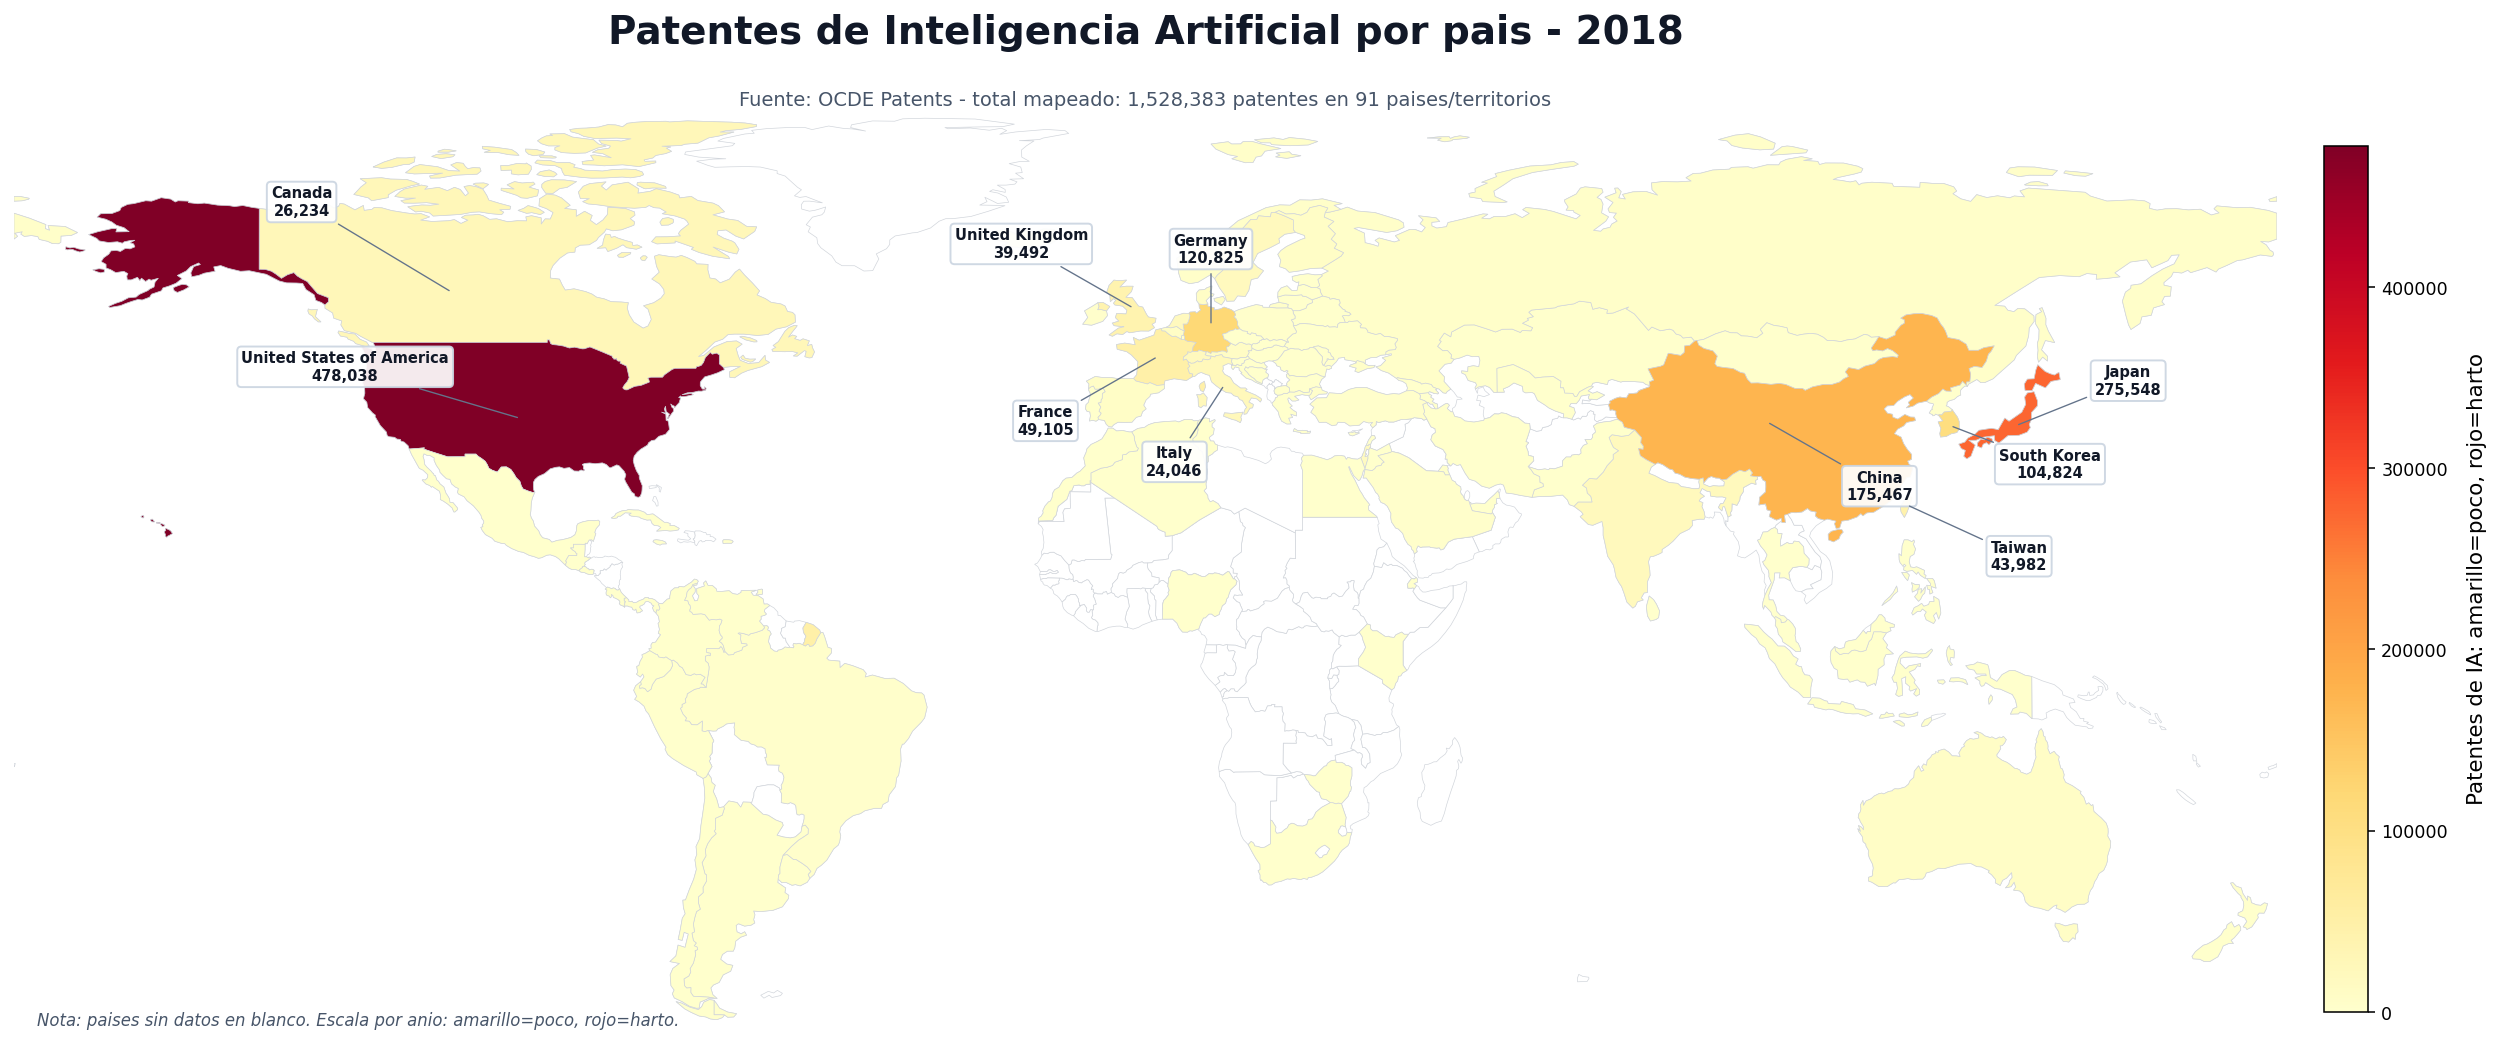

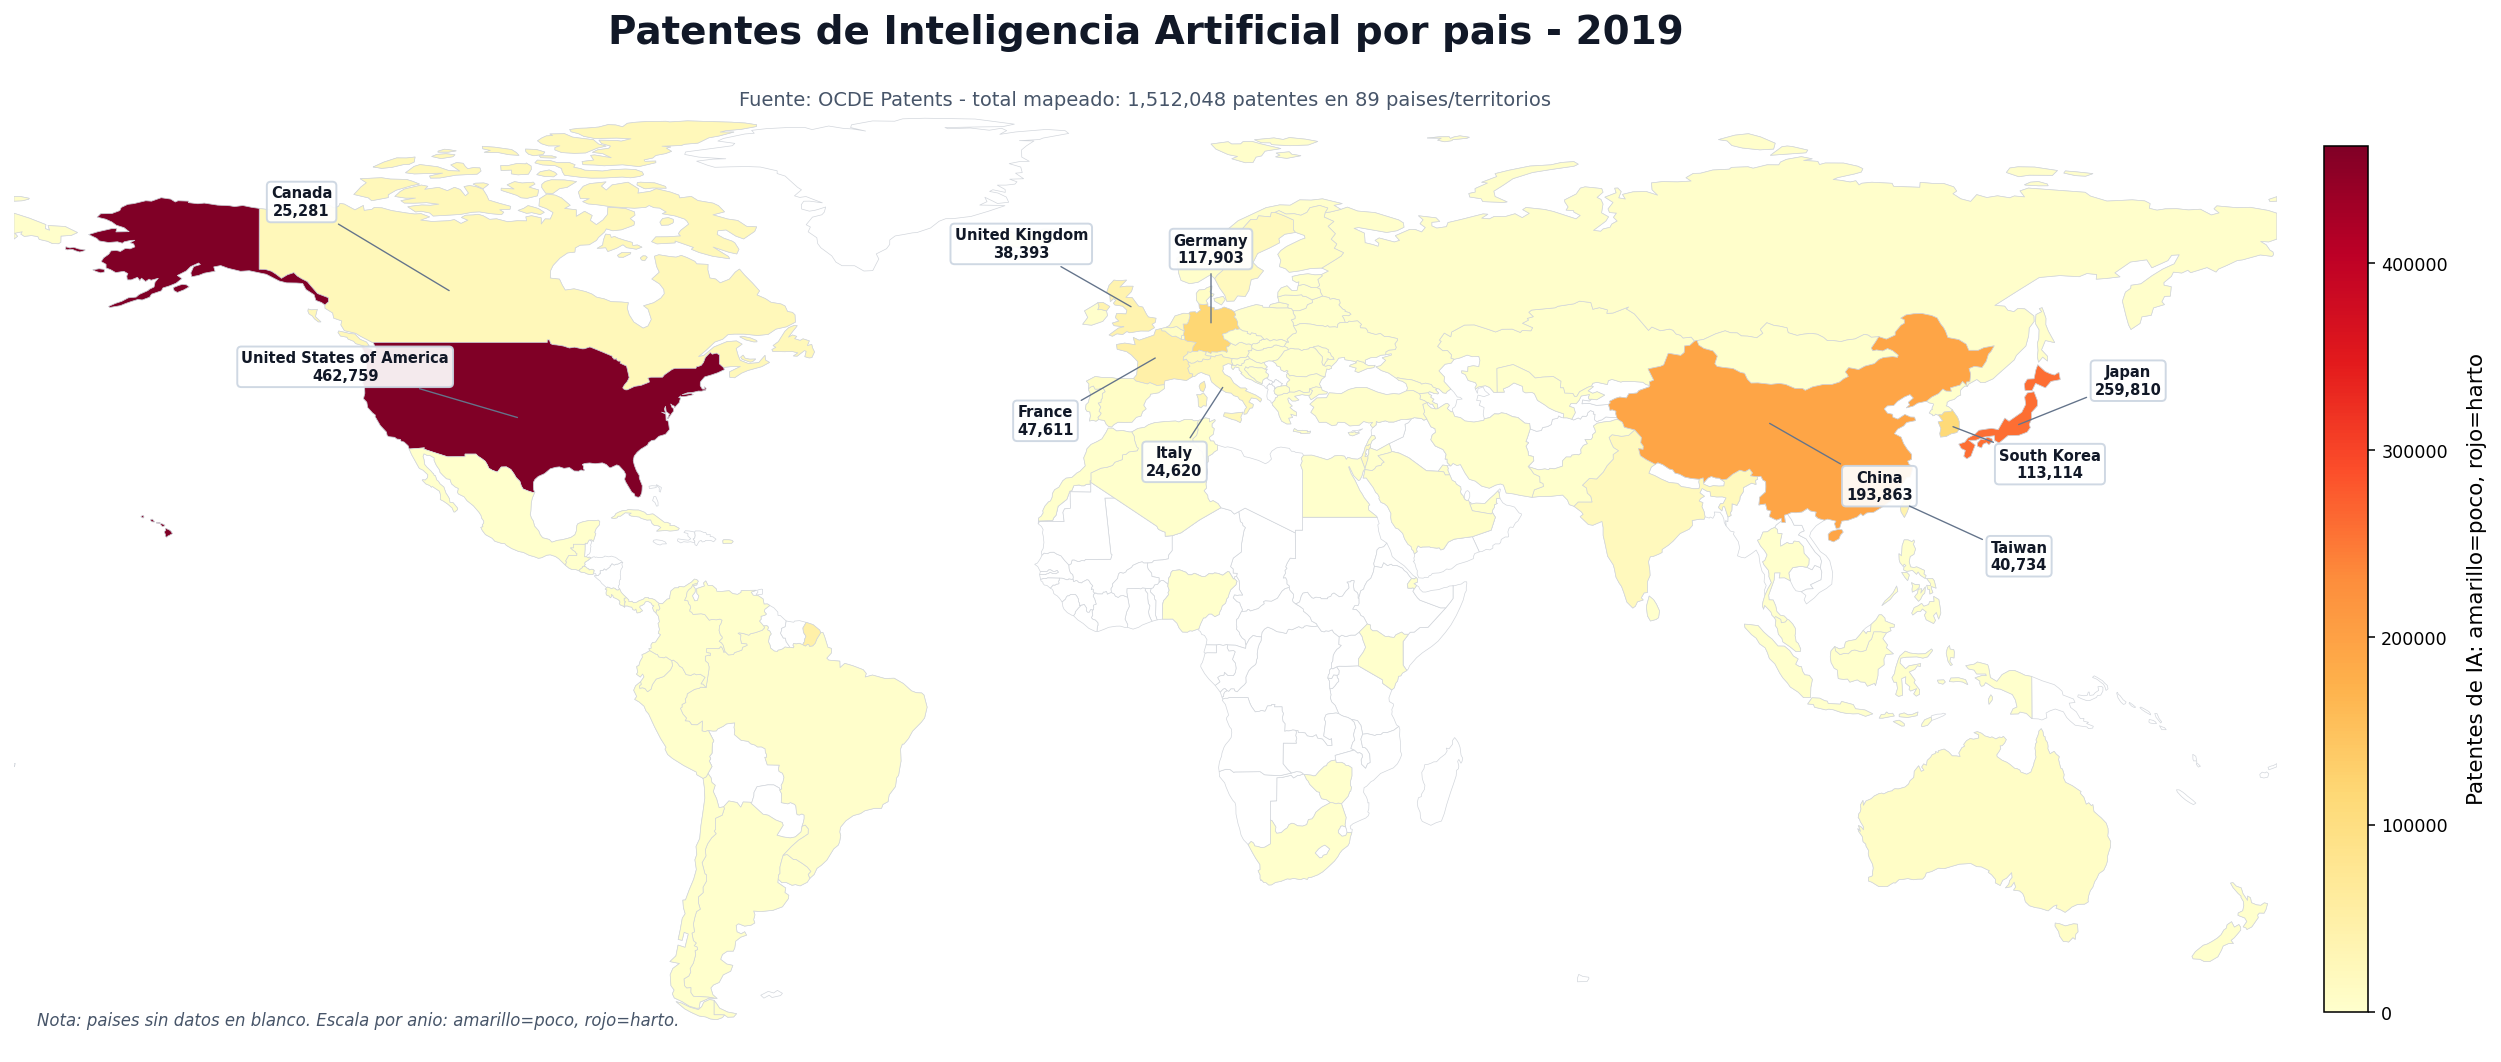

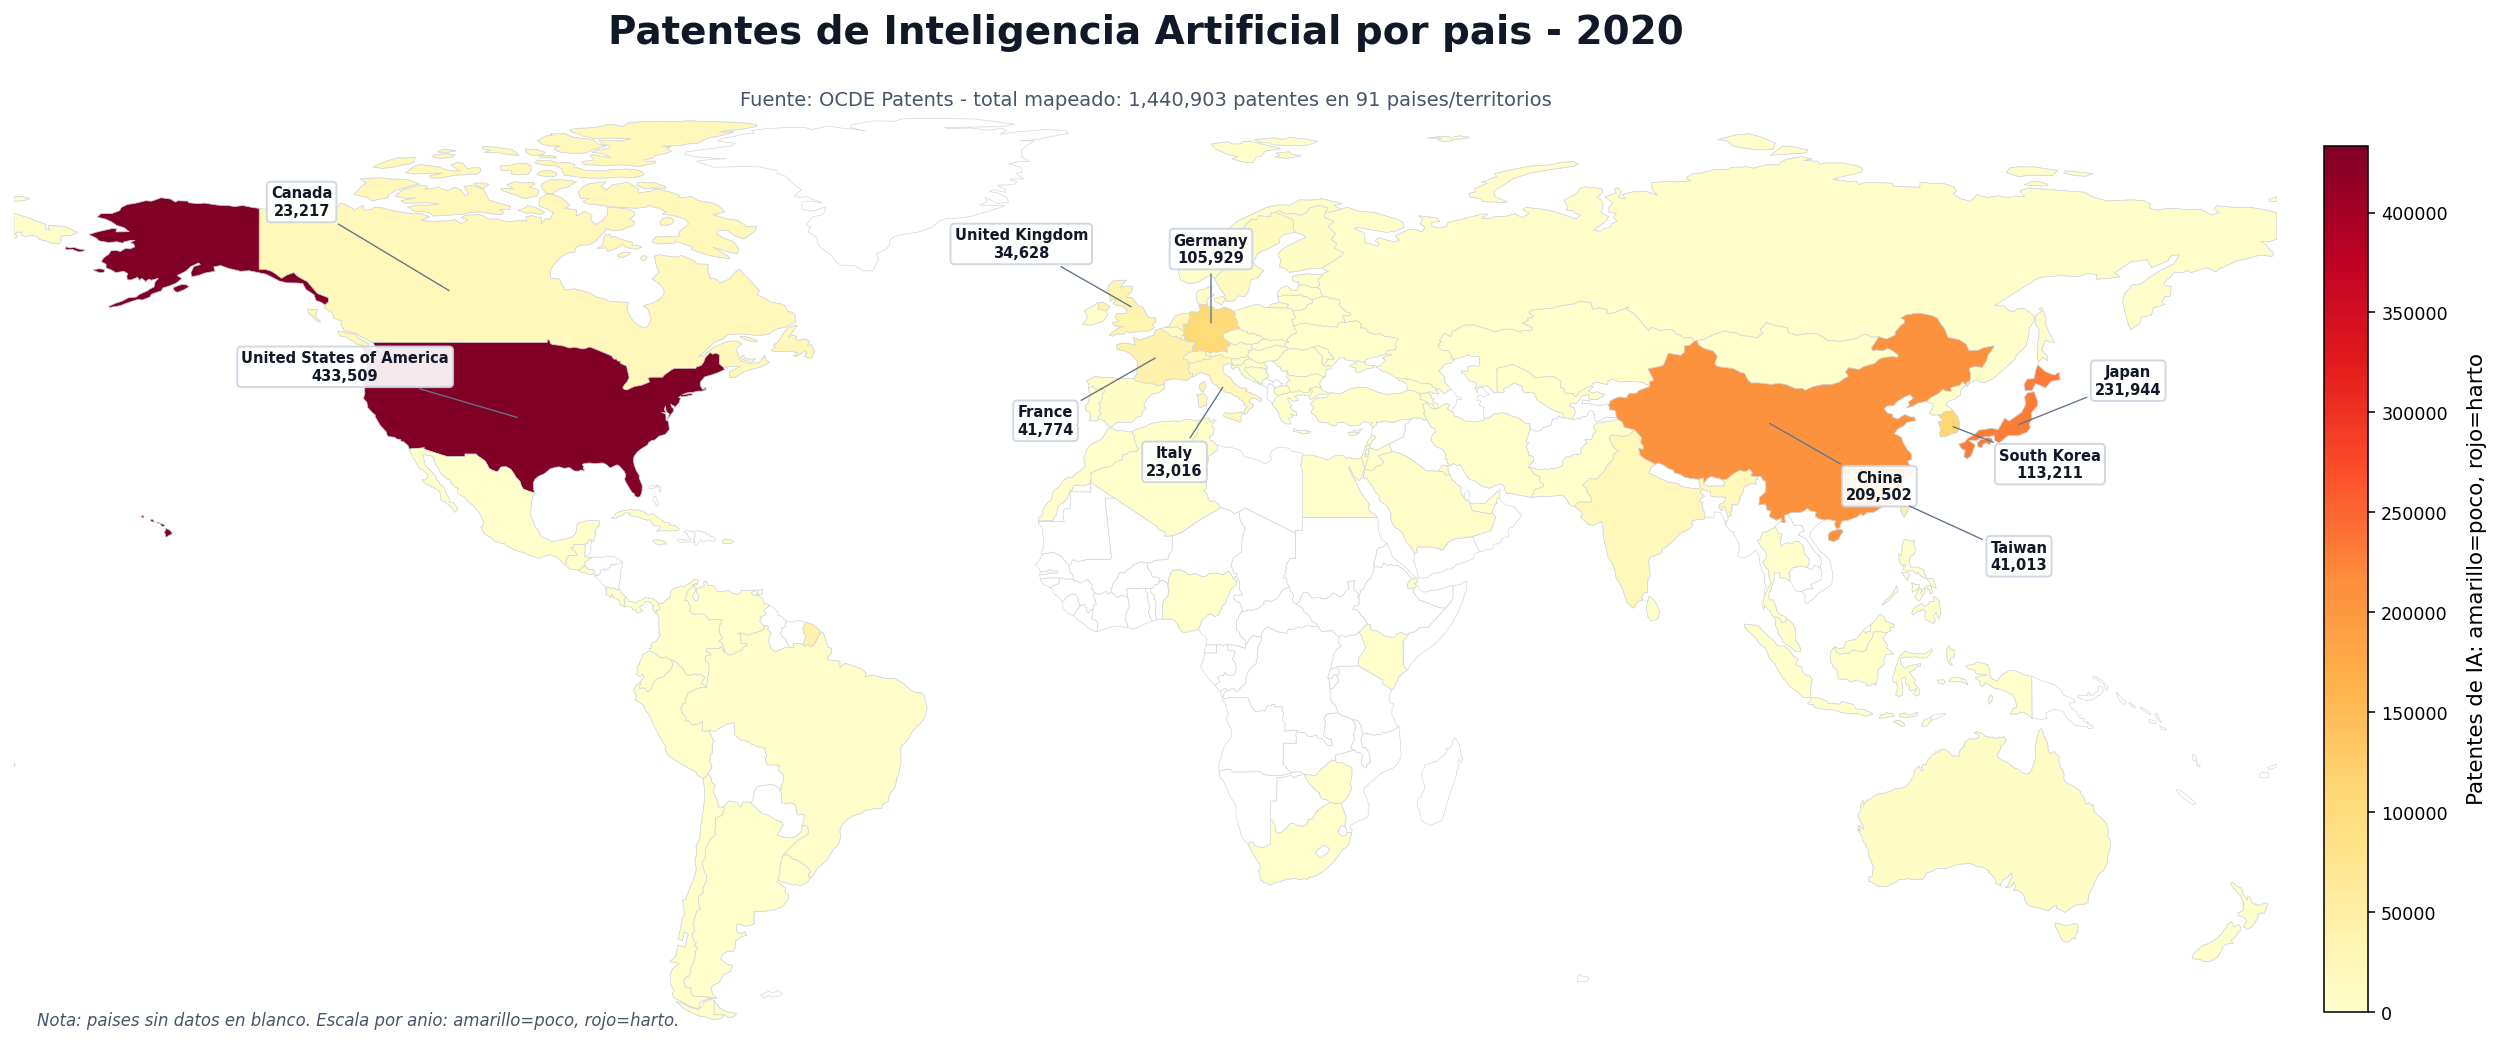

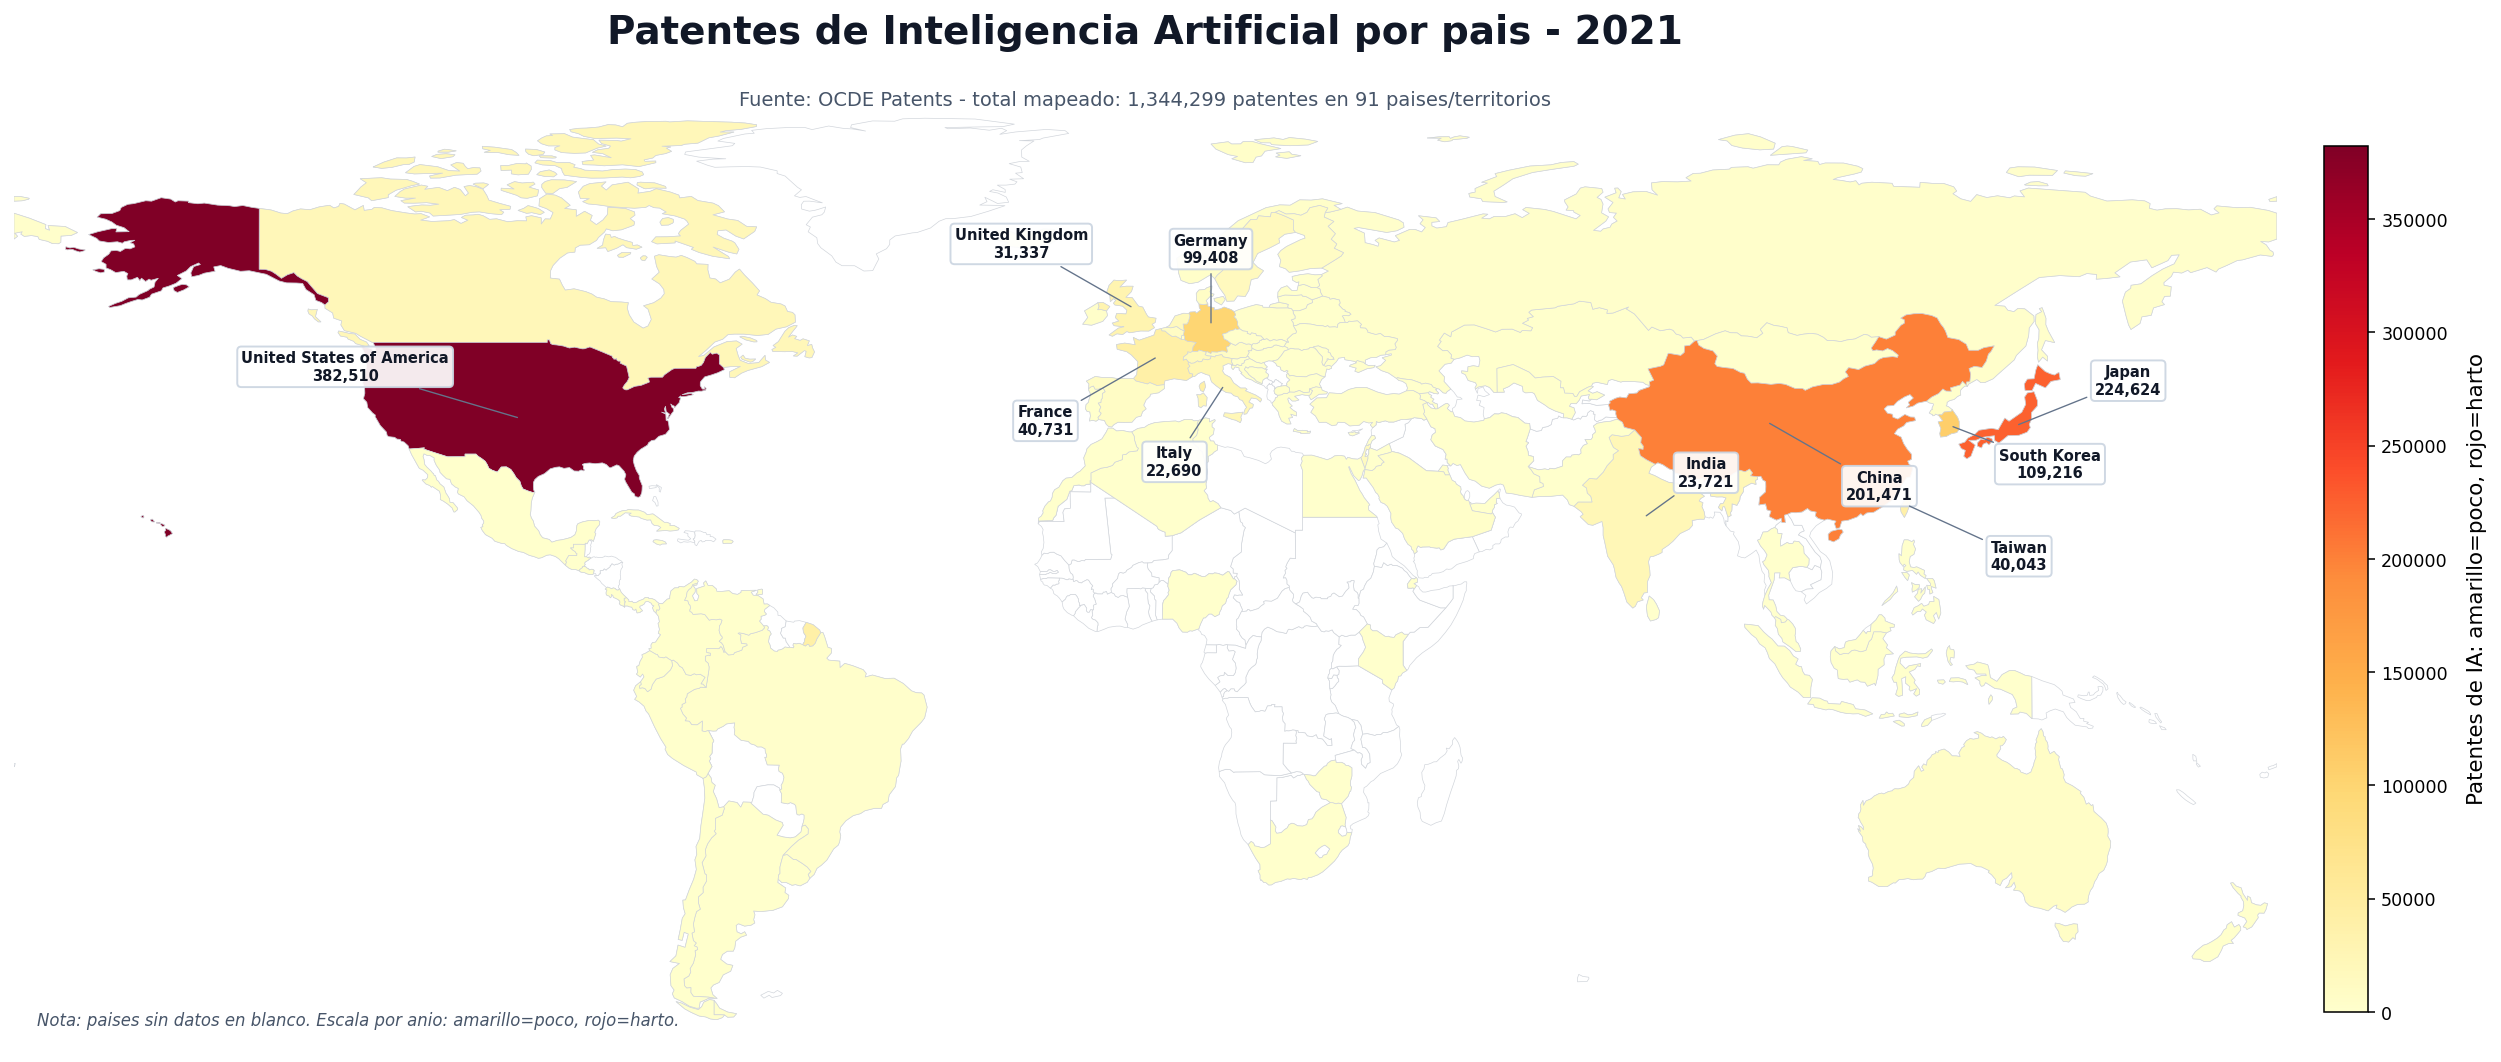

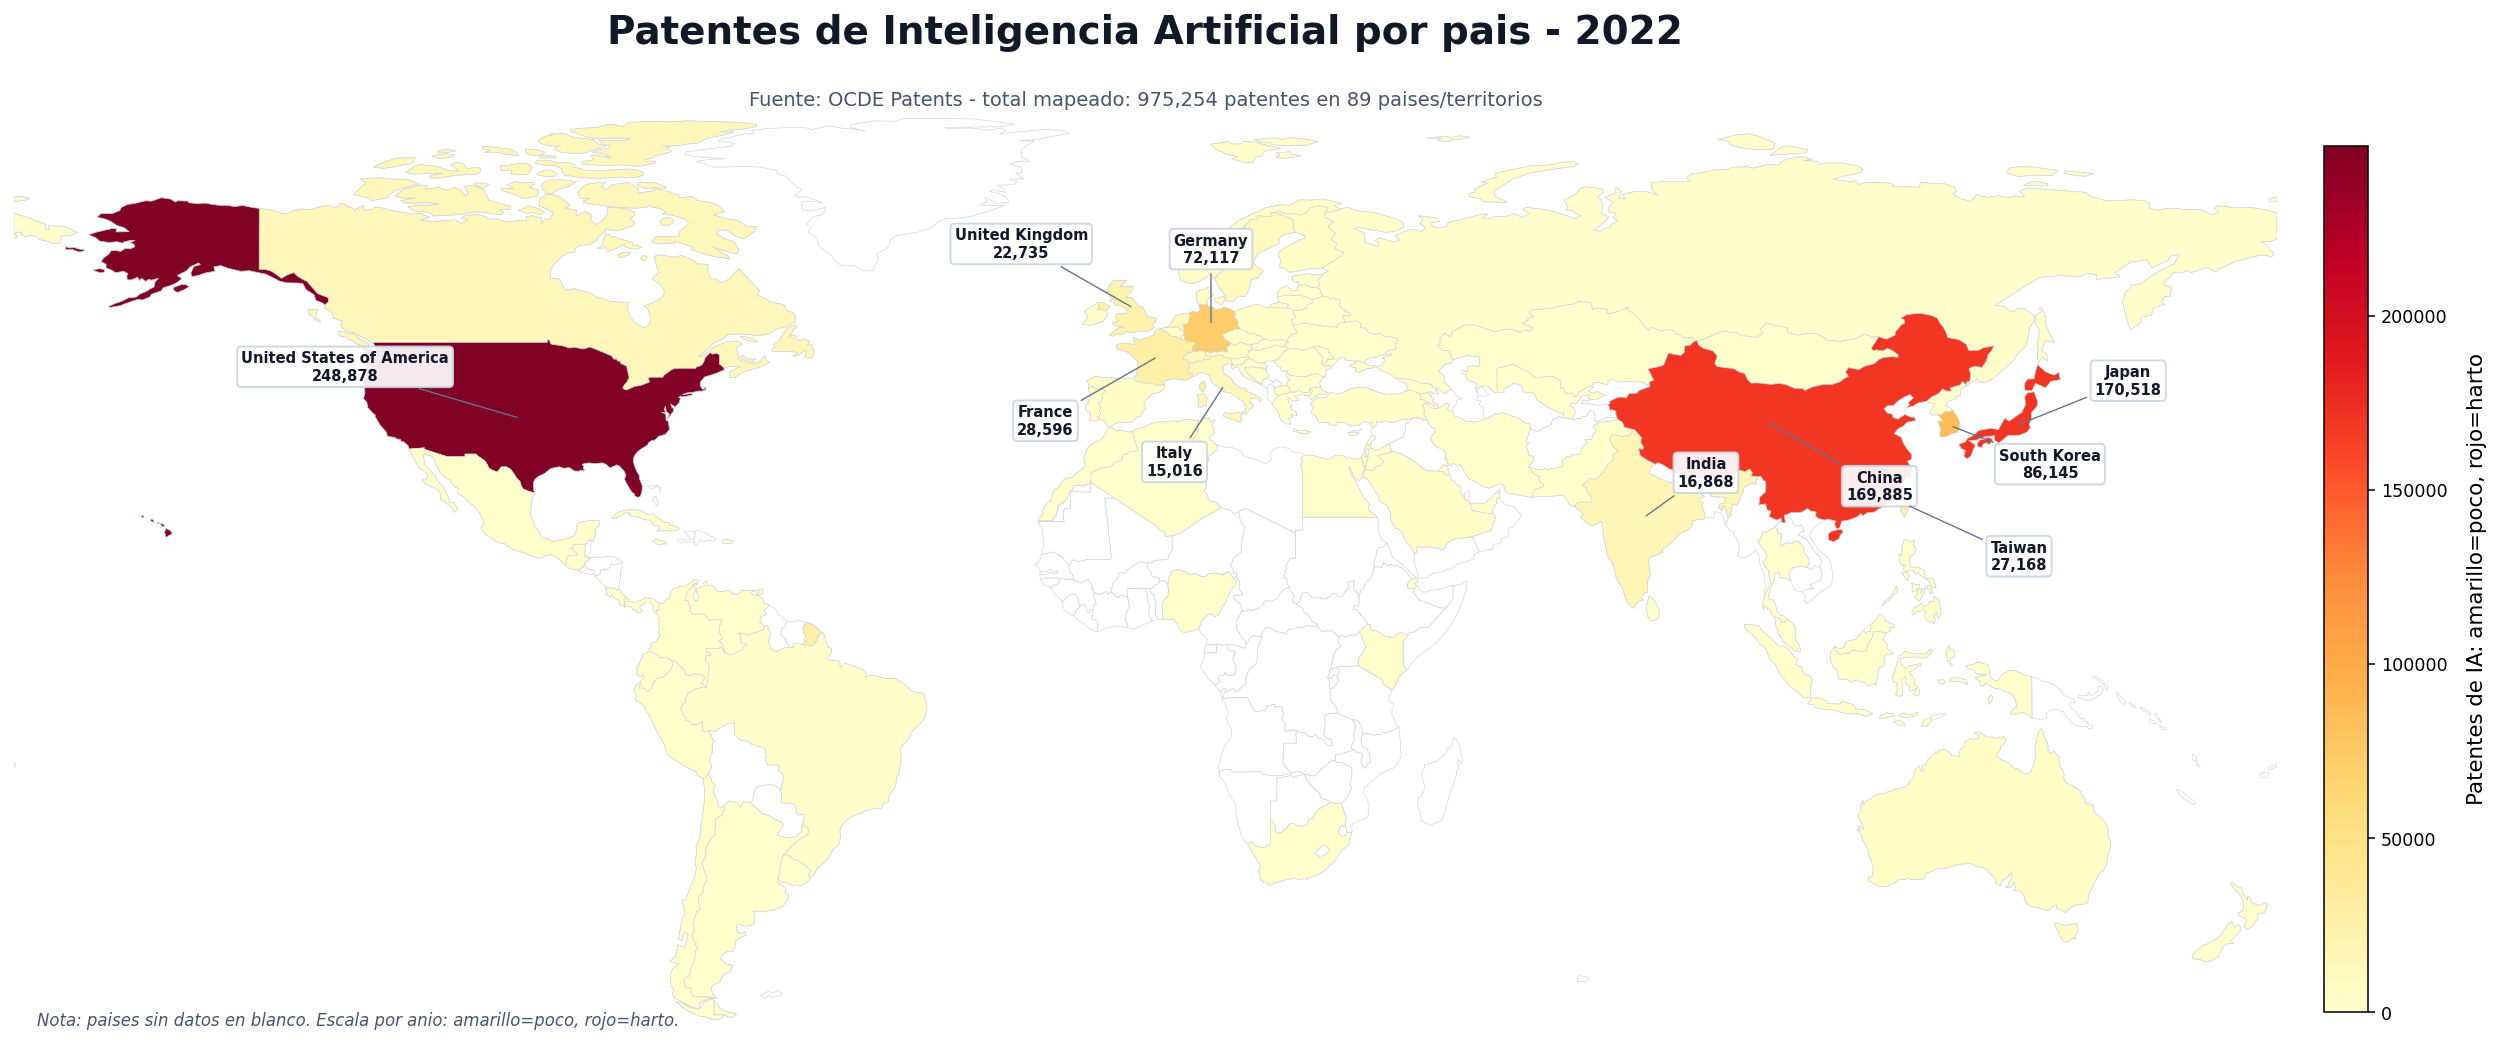

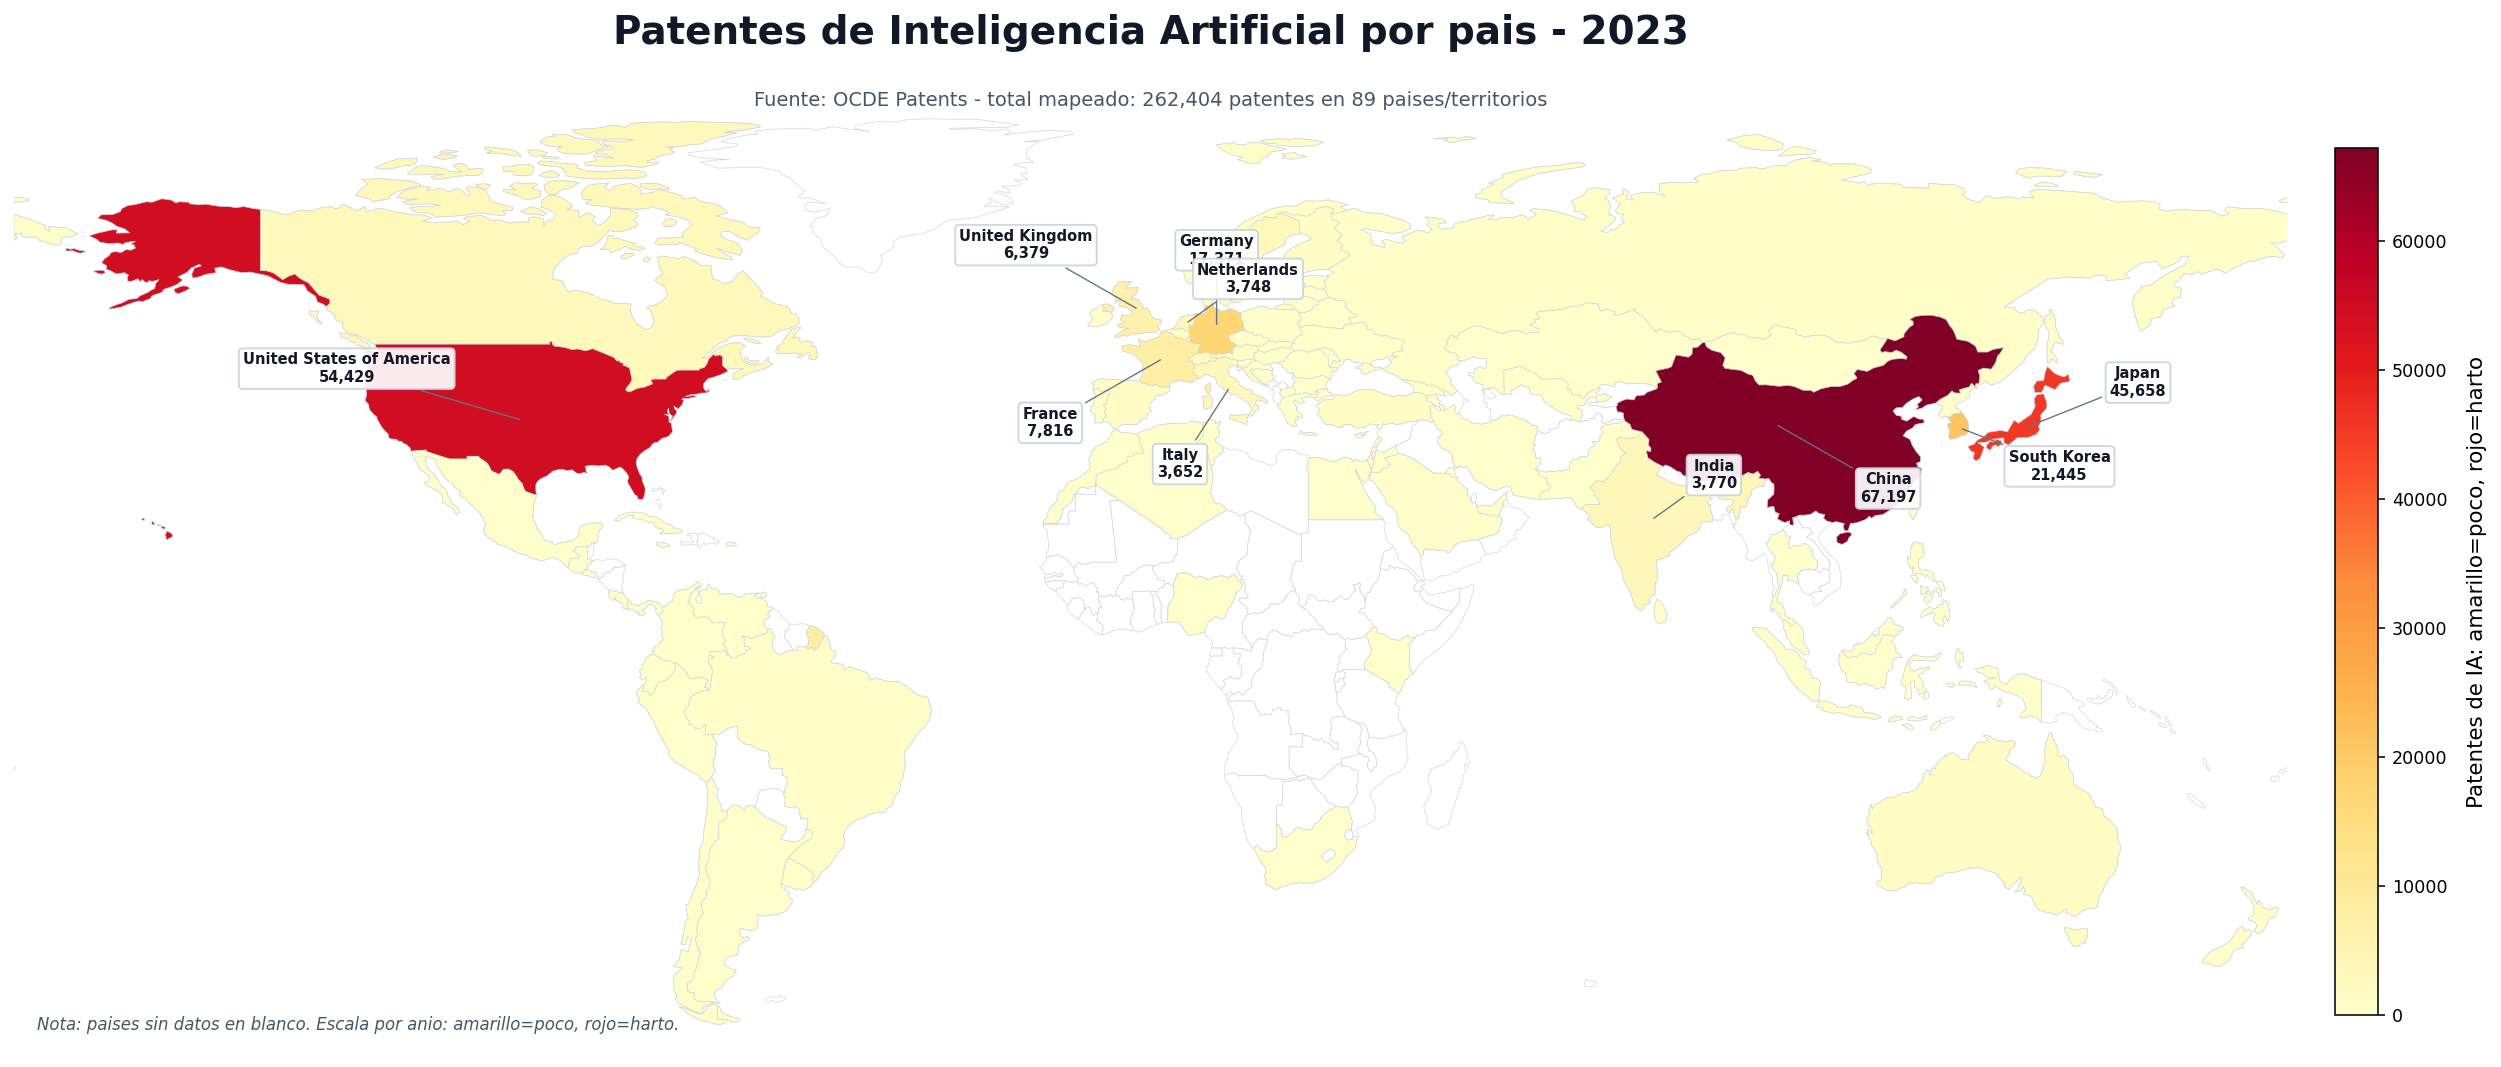

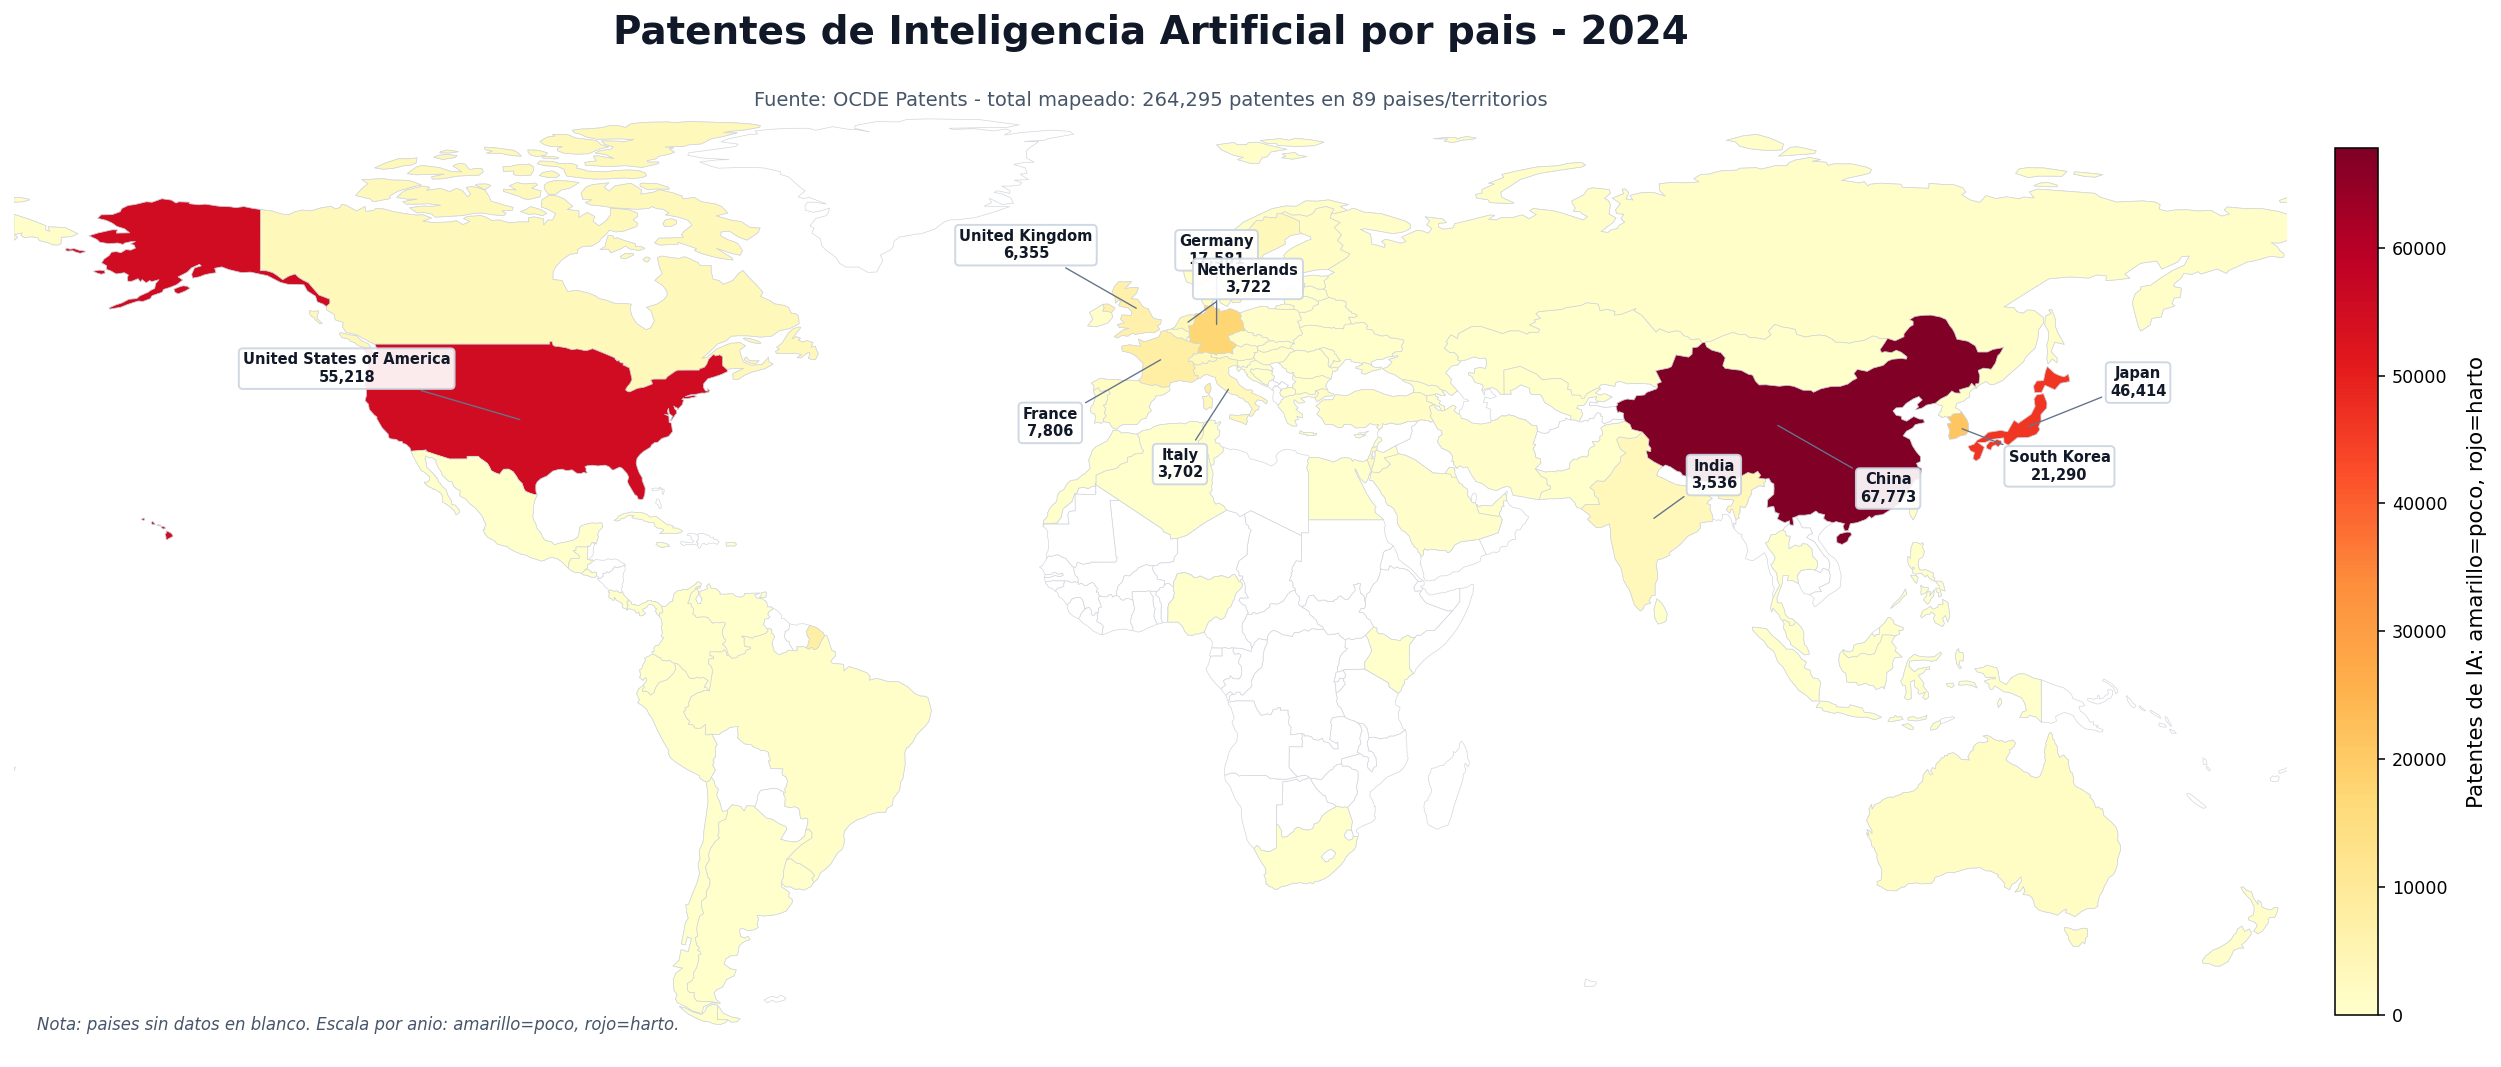

In [6]:
# Generar un mapa para cada anio disponible
map_files = []
for year in years:
    output_png = build_year_map(year, show=True)
    map_files.append(output_png)
    print(f"Mapa {year} guardado en: {output_png}")


In [7]:
# Tabla rapida para apoyar la interpretacion: Top 15 por anio
total_mapeado_por_anio = patents_mappable.groupby("year")["ai_patents"].sum()
summary_top15 = (
    patents_mappable.sort_values(["year", "ai_patents"], ascending=[True, False])
    .groupby("year")
    .head(15)
    .merge(world[["iso3", "NAME"]], on="iso3", how="left")
    .rename(columns={"NAME": "country"})
)
summary_top15["participacion_mapeada_%"] = 100 * summary_top15["ai_patents"] / summary_top15["year"].map(total_mapeado_por_anio)
summary_top15[["year", "country", "iso3", "ai_patents", "participacion_mapeada_%"]]


,year,country,iso3,ai_patents,participacion_mapeada_%
0,2018,United States of America,USA,478038.44700,31.277400
1,2018,Japan,JPN,275548.29200,18.028747
2,2018,China,CHN,175466.61360,11.480540
3,2018,Germany,DEU,120825.01380,7.905415
4,2018,South Korea,KOR,104824.48480,6.858522
5,2018,France,FRA,49104.51510,3.212841
6,2018,Taiwan,TWN,43981.69911,2.877662
7,2018,United Kingdom,GBR,39492.02400,2.583909
8,2018,Canada,CAN,26234.11110,1.716462
9,2018,Italy,ITA,24045.71219,1.573278


In [8]:
# Revision de codigos del CSV que no se dibujaron en los mapas
unmapped_summary = (
    patents.loc[patents["iso3"].isin(unmapped_codes)]
    .groupby("iso3", as_index=False)["ai_patents"]
    .sum()
    .sort_values("ai_patents", ascending=False)
)
unmapped_summary.head(30)


,iso3,ai_patents
11,W,7.391890e+06
8,OECD,5.850721e+06
3,EU27_2020,1.358397e+06
9,SGP,2.632740e+04
4,HKG,1.084822e+04
5,LIE,7.072660e+02
7,MLT,6.554130e+02
6,MCO,4.749038e+02
2,CYM,2.498173e+02
1,BMU,1.000613e+02


## Mapas normalizados por poblacion

Las patentes absolutas favorecen a los paises grandes. Para comparar el esfuerzo relativo de cada pais se normaliza dividiendo el numero de patentes de IA por la poblacion del pais (en millones de habitantes), obteniendo **patentes de IA por millon de habitantes**.

La columna de poblacion proviene del atributo `POP_EST` del mismo archivo de geometria de Natural Earth que ya fue cargado, por lo que no se requiere ninguna fuente de datos adicional.


In [ ]:
# Construir tabla de poblacion desde Natural Earth (columna POP_EST)
# POP_EST esta en habitantes; dividimos por 1_000_000 para trabajar en millones.
pop_df = (
    world[["iso3", "POP_EST"]]
    .dropna(subset=["POP_EST"])
    .copy()
)
pop_df["pop_millions"] = pop_df["POP_EST"].astype(float) / 1_000_000

# Combinar con patents_mappable para obtener la columna normalizada.
# Usamos la poblacion del shapefile (un solo valor por pais); para tendencias
# inter-anuales lo ideal seria poblacion anual, pero aqui se prioriza la
# simplicidad y la fuente unica de datos.
patents_norm = patents_mappable.merge(pop_df[["iso3", "pop_millions"]], on="iso3", how="left")
patents_norm["ai_patents_per_million"] = (
    patents_norm["ai_patents"] / patents_norm["pop_millions"]
)
patents_norm = patents_norm.dropna(subset=["ai_patents_per_million"])
patents_norm = patents_norm[patents_norm["pop_millions"] > 0.1]  # excluir micro-territorios sin poblacion util

print(f"Paises con dato normalizado: {patents_norm['iso3'].nunique()}")
patents_norm.sort_values("ai_patents_per_million", ascending=False).head(10)


In [ ]:
# Directorio de salida para mapas normalizados
OUTPUT_DIR_NORM = OUTPUT_DIR.parent / "mapas_patentes_ia_per_capita"
OUTPUT_DIR_NORM.mkdir(parents=True, exist_ok=True)
print(f"Mapas normalizados: {OUTPUT_DIR_NORM.resolve()}")


def build_year_map_norm(year, show=True):
    """Mapa coropletico de patentes de IA por millon de habitantes para un anio."""
    data_year = patents_norm.loc[patents_norm["year"].eq(year)].copy()
    world_map = world.merge(data_year[["iso3", "ai_patents_per_million"]], on="iso3", how="left")

    positive_year = data_year.loc[data_year["ai_patents_per_million"] > 0, "ai_patents_per_million"]
    vmax_year = float(positive_year.quantile(0.97)) if len(positive_year) > 0 else 1.0  # percentil 97 para no saturar con outliers
    norm_year = mcolors.Normalize(vmin=0, vmax=vmax_year)

    fig, ax = plt.subplots(1, 1, figsize=(18, 10), facecolor="#ffffff")
    ax.set_facecolor("#ffffff")

    # Paises base: blanco significa sin datos.
    world_map.plot(ax=ax, color="#ffffff", edgecolor="#d1d5db", linewidth=0.35)

    # Paises con datos positivos: amarillo bajo, rojo alto.
    has_data = world_map["ai_patents_per_million"].notna() & (world_map["ai_patents_per_million"] > 0)
    world_map.loc[has_data].plot(
        ax=ax,
        column="ai_patents_per_million",
        cmap=cmap_patentes,
        norm=norm_year,
        edgecolor="#d1d5db",
        linewidth=0.35,
        legend=False,
    )

    sm = plt.cm.ScalarMappable(cmap=cmap_patentes, norm=norm_year)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.68)
    cbar.set_label("Patentes de IA por millon de hab.: amarillo=poco, rojo=harto", fontsize=11, labelpad=10)
    cbar.ax.tick_params(labelsize=9)

    # Etiquetas para el Top 10 normalizado de cada anio.
    centroids = world_map.loc[has_data].copy()
    centroids["point"] = centroids.geometry.representative_point()
    centroids = centroids.sort_values("ai_patents_per_million", ascending=False).head(10)

    for _, row in centroids.iterrows():
        iso = row["iso3"]
        point = row["point"]
        dx, dy = label_offsets.get(iso, (10, 7))
        label = f"{row['NAME']}\n{row['ai_patents_per_million']:,.1f}"
        ax.annotate(
            label,
            xy=(point.x, point.y),
            xytext=(point.x + dx, point.y + dy),
            fontsize=7.5,
            color="#111827",
            fontweight="bold",
            ha="center",
            va="center",
            arrowprops=dict(arrowstyle="-", color="#64748b", lw=0.7),
            bbox=dict(boxstyle="round,pad=0.28", facecolor="#ffffff", edgecolor="#cbd5e1", alpha=0.92),
        )

    countries = data_year.loc[data_year["ai_patents_per_million"] > 0, "iso3"].nunique()
    ax.set_title(
        f"Patentes de Inteligencia Artificial por millon de habitantes - {year}",
        fontsize=20,
        fontweight="bold",
        color="#111827",
        pad=34,
    )
    ax.text(
        0.5,
        1.000,
        f"Fuente: OCDE Patents + Natural Earth (POP_EST) - {countries} paises/territorios con dato",
        transform=ax.transAxes,
        fontsize=10,
        color="#475569",
        ha="center",
        va="bottom",
    )
    ax.text(
        0.01,
        0.02,
        "Nota: paises sin datos en blanco. Escala por anio (percentil 97): amarillo=poco, rojo=harto.",
        transform=ax.transAxes,
        fontsize=8.5,
        color="#475569",
        va="bottom",
        fontstyle="italic",
    )

    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    output_png = OUTPUT_DIR_NORM / f"mapa_patentes_ia_per_capita_{year}.png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())

    if show:
        plt.show()
    else:
        plt.close(fig)

    return output_png


In [ ]:
# Generar un mapa normalizado para cada anio disponible
map_files_norm = []
for year in years:
    output_png = build_year_map_norm(year, show=True)
    map_files_norm.append(output_png)
    print(f"Mapa normalizado {year} guardado en: {output_png}")
